# 🧠 Human Facial Expression Recognition




### Import Libraries


In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random


import warnings
warnings.filterwarnings("ignore")


### GPU

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Hyperparameters

In [6]:
BATCH_SIZE = 64
LR = 5e-4
EPOCHS = 60
NUM_CLASSES = 7



### Data Preprocessing & Augmentation


In [7]:
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [8]:
# Transform to be used for prediction / Flask app
inference_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


## Dataset Overview



### 🔹 Dataset Details
- Image size: **48 × 48**
- Image type: **Grayscale**
- Number of classes: **7**

### 🔹 Emotion Classes
- 😊 Happy
- 😢 Sad
- 😠 Angry
- 😨 Fear
- 😲 Surprise
- 😐 Neutral
- 🤢 Disgust


<a id="6-1"></a>
### Load the dataset

In [ ]:
!unzip Facial\ Expression\ Recognition.zip

In [10]:
train_dataset = datasets.ImageFolder(
    "/content/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "/content/test",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print("Classes:", train_dataset.classes)


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [11]:
emotion_labels = train_dataset.classes
print(emotion_labels)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


<a id="6-2"></a>
### Sample Images Visualization


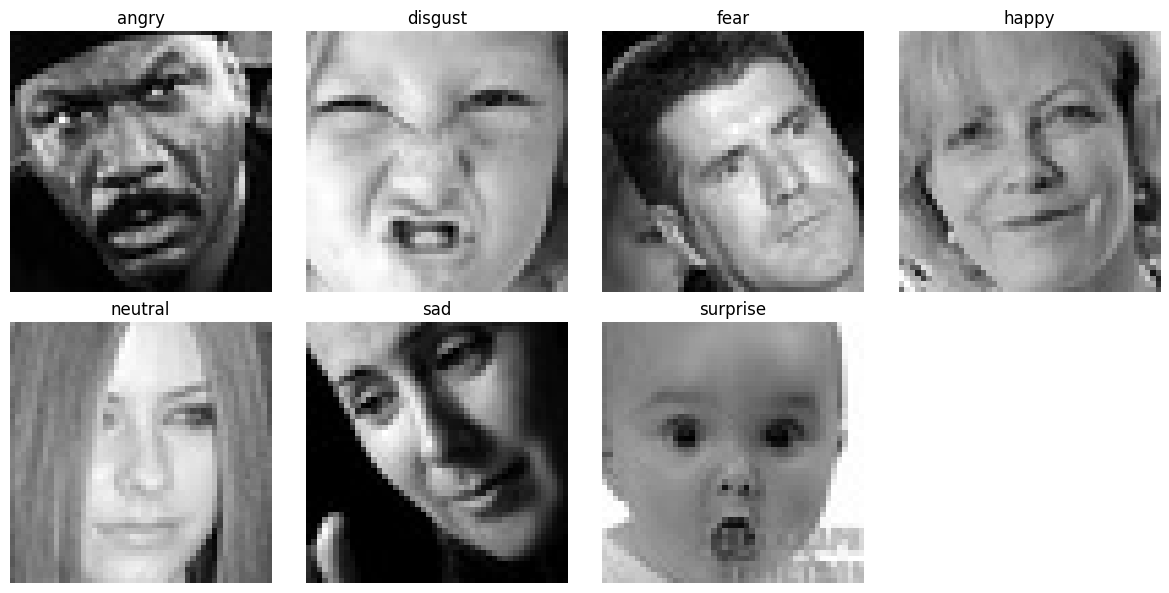

In [12]:

root_dir = train_dataset.root
classes = train_dataset.classes

plt.figure(figsize=(12,6))

for i, emotion in enumerate(classes):
    class_dir = os.path.join(root_dir, emotion)
    img_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_name)
    img = plt.imread(img_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
targets = [y for _, y in train_dataset.samples]
class_count = Counter(targets)

weights = torch.tensor(
    [1.0 / class_count[i] for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)


<a id="8-1"></a>
### CNN Model

In [14]:
class FER_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 5, padding=2),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 3 * 3, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.25),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.25),

            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = FER_CNN().to(device)


In [15]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)



### Training Loop


In [16]:
train_loss, train_acc = [], []
val_loss, val_acc = [], []

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0, 0, 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if train:
                optimizer.zero_grad()

            out = model(x)
            loss = criterion(out, y)

            if train:
                loss.backward()
                optimizer.step()

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total


for epoch in range(EPOCHS):
    tr_l, tr_a = run_epoch(train_loader, True)
    va_l, va_a = run_epoch(val_loader, False)

    scheduler.step(va_a)

    train_loss.append(tr_l)
    train_acc.append(tr_a)
    val_loss.append(va_l)
    val_acc.append(va_a)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Acc: {tr_a:.4f} | Val Acc: {va_a:.4f}"
    )


Epoch [1/60] | Train Acc: 0.2300 | Val Acc: 0.3082
Epoch [2/60] | Train Acc: 0.3276 | Val Acc: 0.3703
Epoch [3/60] | Train Acc: 0.4049 | Val Acc: 0.4551
Epoch [4/60] | Train Acc: 0.4469 | Val Acc: 0.4933
Epoch [5/60] | Train Acc: 0.4728 | Val Acc: 0.5109
Epoch [6/60] | Train Acc: 0.4929 | Val Acc: 0.5075
Epoch [7/60] | Train Acc: 0.5155 | Val Acc: 0.5517
Epoch [8/60] | Train Acc: 0.5309 | Val Acc: 0.5694
Epoch [9/60] | Train Acc: 0.5399 | Val Acc: 0.5694
Epoch [10/60] | Train Acc: 0.5498 | Val Acc: 0.5736
Epoch [11/60] | Train Acc: 0.5533 | Val Acc: 0.5840
Epoch [12/60] | Train Acc: 0.5638 | Val Acc: 0.5879
Epoch [13/60] | Train Acc: 0.5706 | Val Acc: 0.5793
Epoch [14/60] | Train Acc: 0.5618 | Val Acc: 0.5836
Epoch [15/60] | Train Acc: 0.5765 | Val Acc: 0.5971
Epoch [16/60] | Train Acc: 0.5855 | Val Acc: 0.6045
Epoch [17/60] | Train Acc: 0.5892 | Val Acc: 0.5936
Epoch [18/60] | Train Acc: 0.6001 | Val Acc: 0.6095
Epoch [19/60] | Train Acc: 0.5986 | Val Acc: 0.6039
Epoch [20/60] | Train

<a id="10-1"></a>
### Training vs Validation Accuracy

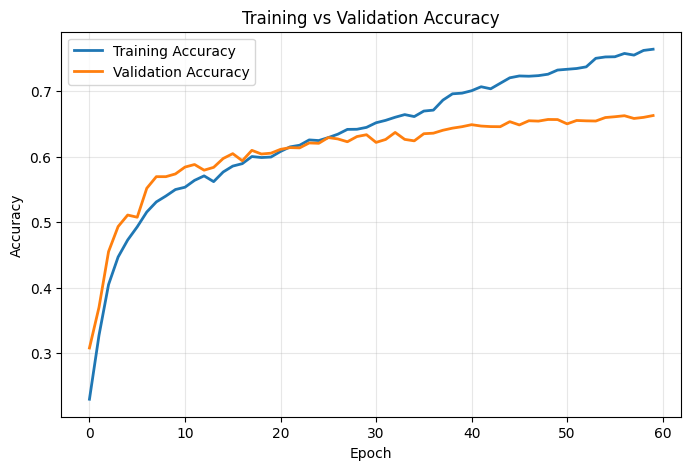

In [17]:
plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Training Accuracy", linewidth=2)
plt.plot(val_acc, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


<a id="10-2"></a>
### Training vs Validation Loss

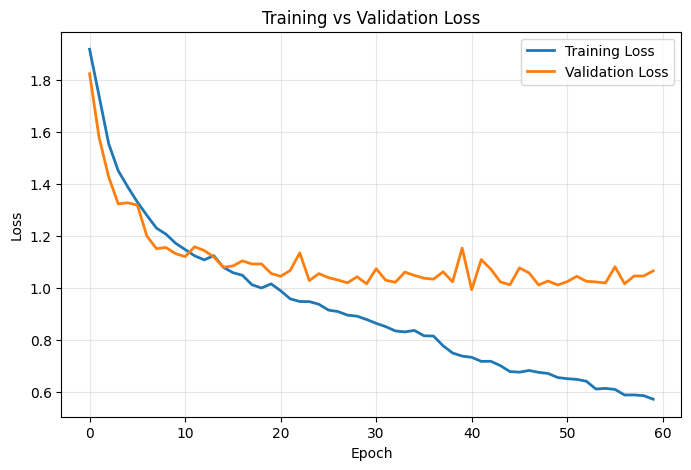

In [18]:
plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Training Loss", linewidth=2)
plt.plot(val_loss, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Confusion Matrix


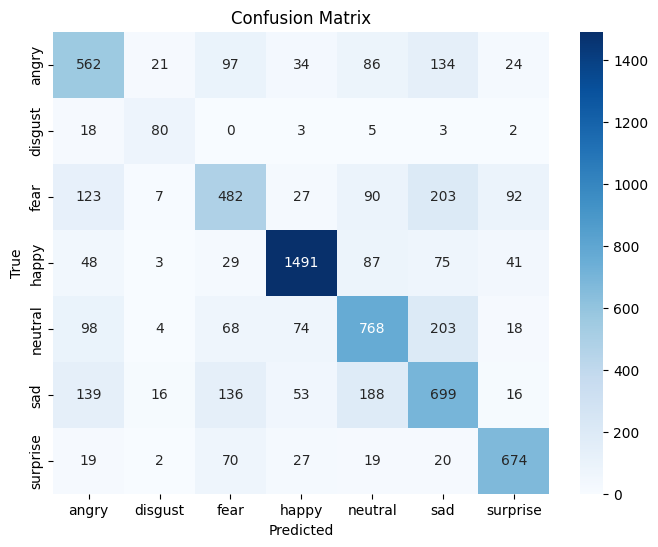

In [19]:
from sklearn.metrics import confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [20]:
# -------- SINGLE IMAGE INFERENCE TEST --------

from PIL import Image

model.eval()

img = Image.open("/content/train/angry/Training_10118481.jpg")  # upload a face image first
img = inference_transform(img)
img = img.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img)
    pred_idx = output.argmax(1).item()

print("Predicted Emotion:", emotion_labels[pred_idx])


Predicted Emotion: angry


### Prediction Gallery


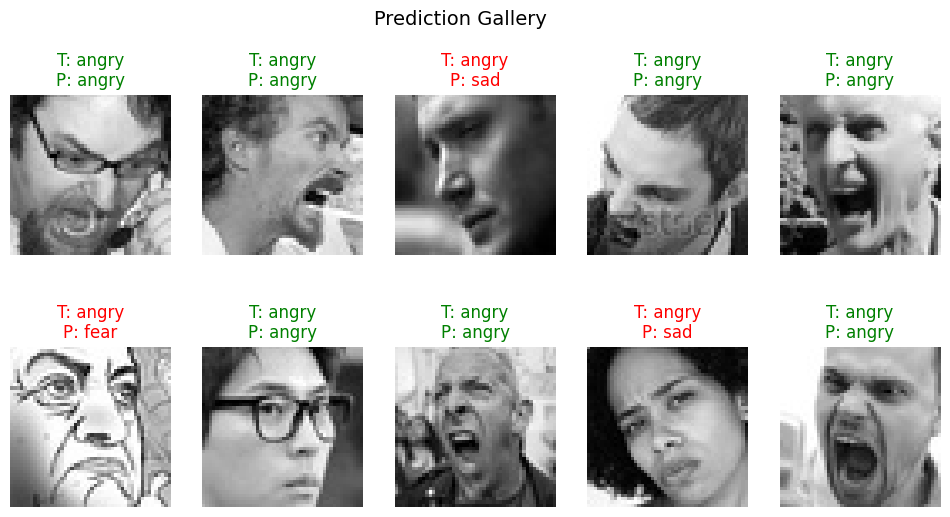

In [21]:
model.eval()
plt.figure(figsize=(12,6))
shown = 0

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)

        for i in range(x.size(0)):
            if shown >= 10:
                break

            img = x[i].cpu().squeeze()
            true = train_dataset.classes[y[i]]
            pred = train_dataset.classes[preds[i]]

            plt.subplot(2,5,shown+1)
            plt.imshow(img, cmap="gray")
            plt.title(
                f"T: {true}\nP: {pred}",
                color="green" if true == pred else "red"
            )
            plt.axis("off")
            shown += 1

        if shown >= 10:
            break

plt.suptitle("Prediction Gallery", fontsize=14)
plt.show()


In [22]:
# Save trained model
MODEL_PATH = "emotion_model.pth"
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved as", MODEL_PATH)


Model saved as emotion_model.pth


In [23]:
from google.colab import files
files.download("emotion_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Conclusion

This notebook demonstrates that:

* Plain CNNs can reach ~67% accuracy
* Further gains require architectural changes rather than more epochs

Possible Extensions
* Upgrade to ResNet18 or EfficientNet
* Apply Vision Transformers (ViT)
* Use Grad-CAM for interpretability